# Feature Engineering Visualization

In [1]:

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (14, 4)})

from src.features.engineering import build_features
from src.utils.config import SLICE_CONFIGS


In [2]:

# 1. Load data and build features
print("Loading eMBB synthetic data...")
df = pd.read_parquet("../data/raw/generated/embb_synthetic.parquet")
# Use a subset of data to avoid overwhelming plots
df = df.iloc[:288*7].copy() # 1 week of data

feats = build_features(df, "eMBB")
print(f"Feature matrix shape: {feats.shape}")
print(f"Columns: ", list(feats.columns)[:10], "...")


Loading eMBB synthetic data...
Feature matrix shape: (2016, 319)
Columns:  ['timestamp', 'slice_type', 'event_type', 'dl_throughput', 'latency', 'jitter', 'packet_loss', 'prb_util', 'active_users', 'reliability'] ...


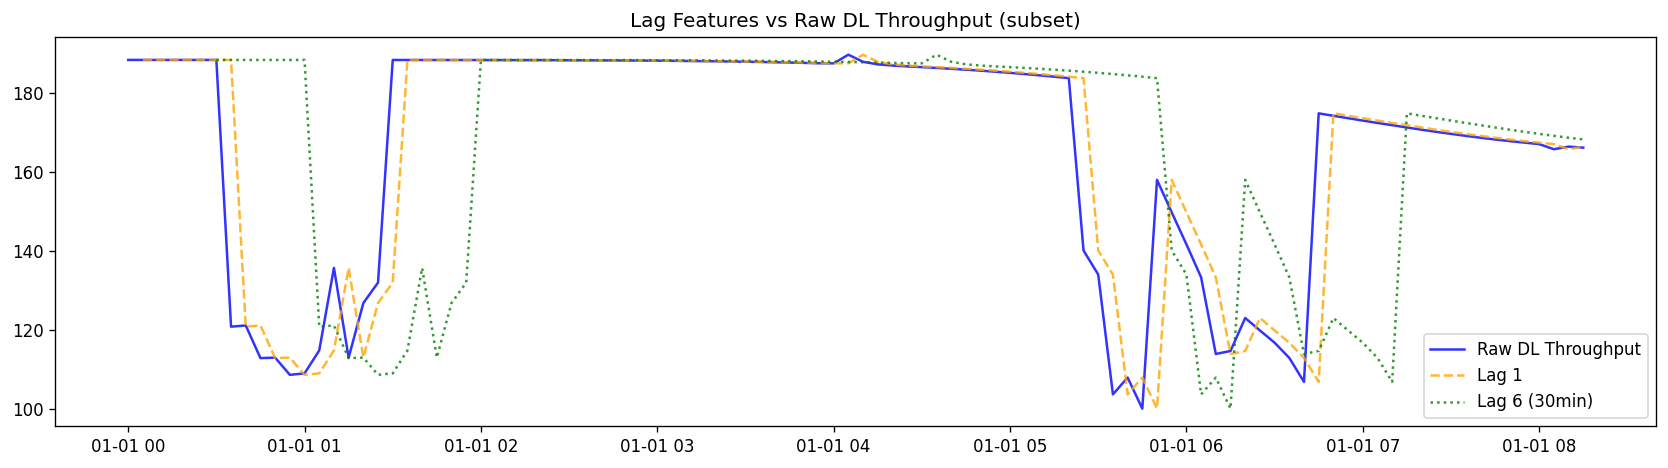

In [3]:

# 2. Lag features vs raw KPI
fig, ax = plt.subplots()
ax.plot(feats['timestamp'].iloc[:100], feats['dl_throughput'].iloc[:100], label='Raw DL Throughput', alpha=0.8, color='blue')
ax.plot(feats['timestamp'].iloc[:100], feats['dl_throughput_lag1'].iloc[:100], label='Lag 1', alpha=0.8, linestyle='--', color='orange')
ax.plot(feats['timestamp'].iloc[:100], feats['dl_throughput_lag6'].iloc[:100], label='Lag 6 (30min)', alpha=0.8, linestyle=':', color='green')
ax.set_title("Lag Features vs Raw DL Throughput (subset)")
ax.legend()
plt.tight_layout()
plt.show()


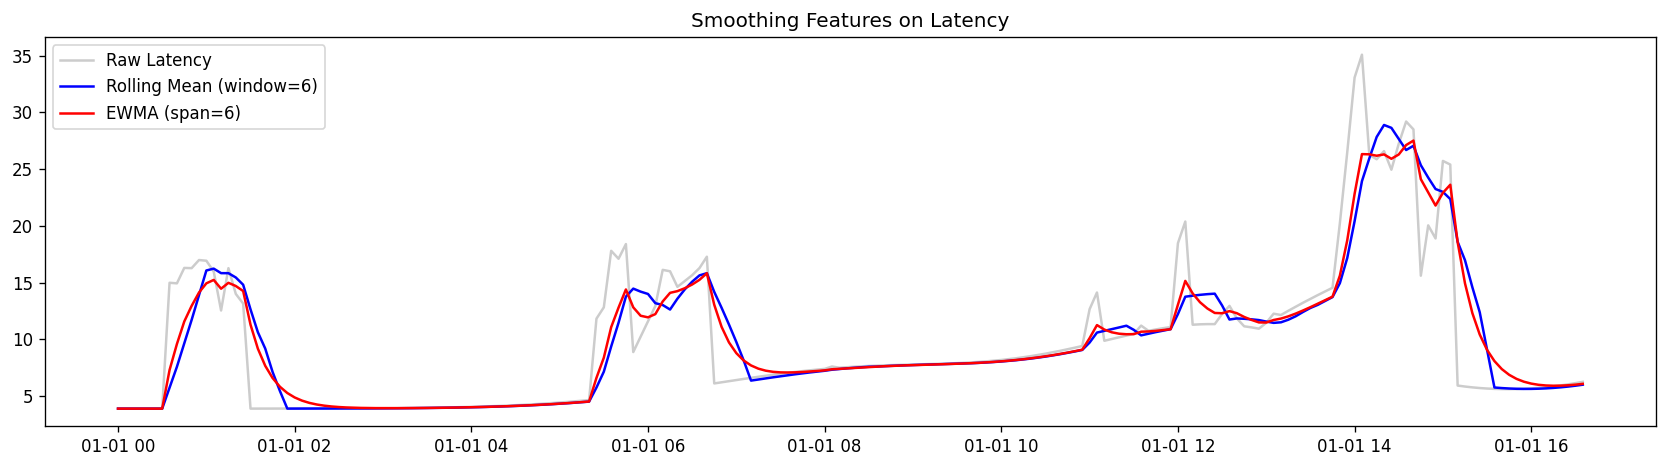

In [4]:

# 3. Rolling Mean vs EWMA
fig, ax = plt.subplots()
ax.plot(feats['timestamp'].iloc[0:200], feats['latency'].iloc[0:200], label='Raw Latency', alpha=0.4, color='gray')
ax.plot(feats['timestamp'].iloc[0:200], feats['latency_roll6_mean'].iloc[0:200], label='Rolling Mean (window=6)', color='blue')
ax.plot(feats['timestamp'].iloc[0:200], feats['latency_ewma6'].iloc[0:200], label='EWMA (span=6)', color='red')
ax.set_title("Smoothing Features on Latency")
ax.legend()
plt.tight_layout()
plt.show()


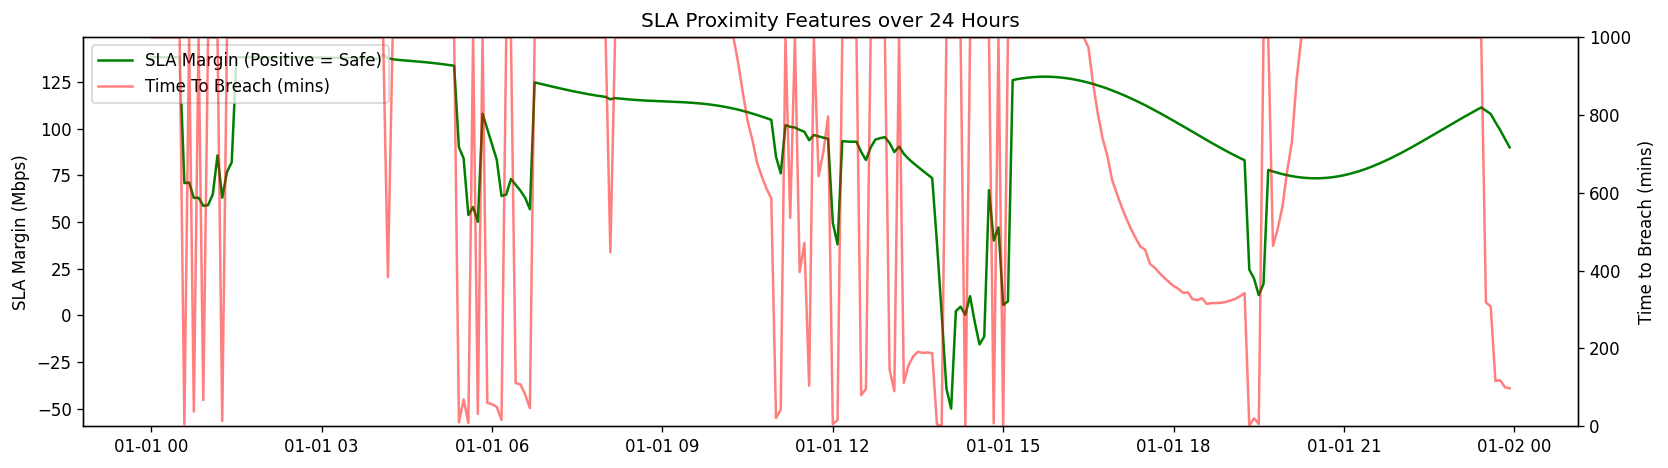

In [5]:

# 4. SLA Proximity (1 day)
start = 0
end = 288 # 1 day

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(feats['timestamp'].iloc[start:end], feats['dl_throughput_sla_margin'].iloc[start:end], label='SLA Margin (Positive = Safe)', color='green')
ax2.plot(feats['timestamp'].iloc[start:end], feats['dl_throughput_time_to_breach'].iloc[start:end], label='Time To Breach (mins)', color='red', alpha=0.5)

ax1.set_ylabel('SLA Margin (Mbps)')
ax2.set_ylabel('Time to Breach (mins)')
ax2.set_ylim(0, 1000)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title("SLA Proximity Features over 24 Hours")
plt.tight_layout()
plt.show()


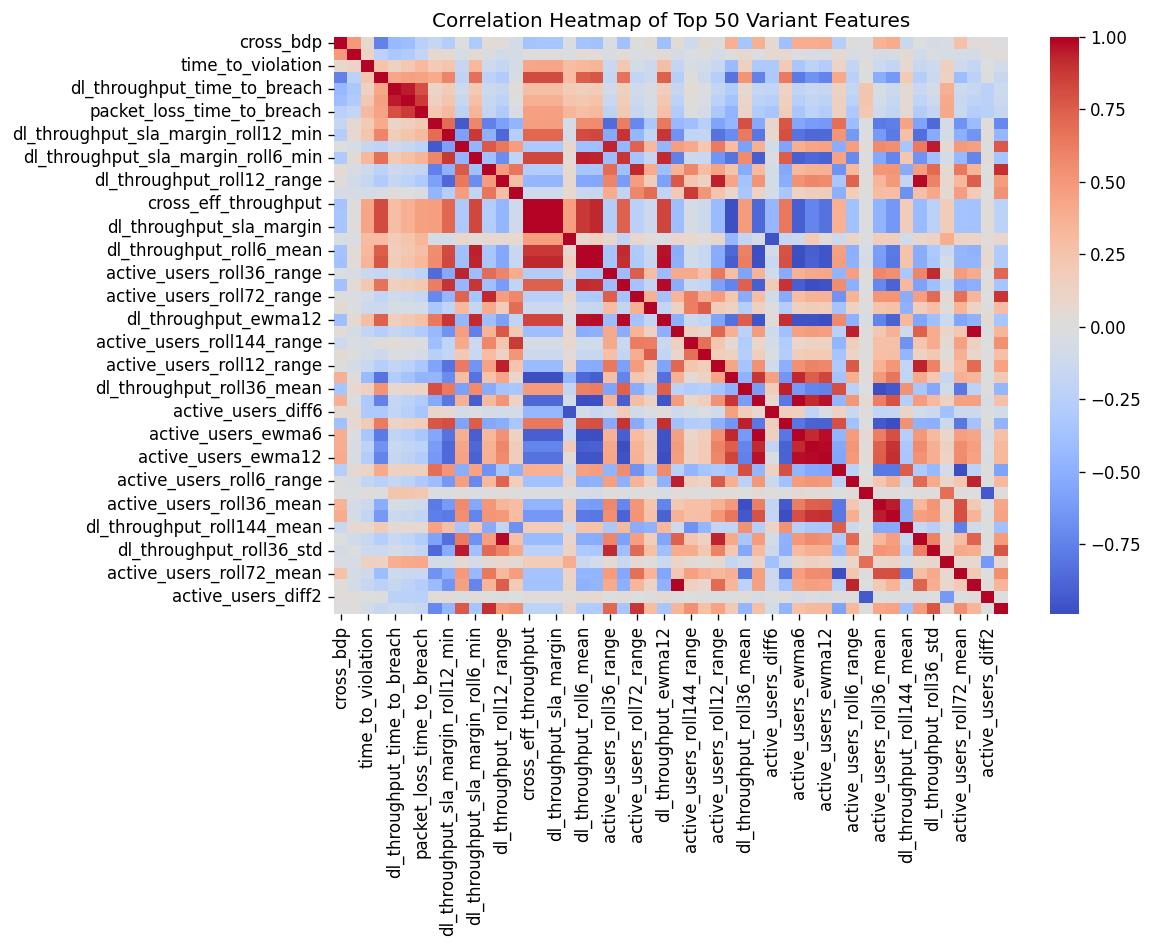

In [6]:

# 5. Feature Correlation Heatmap (Top 50 features by variance)
numeric_feats = feats.select_dtypes(include=[np.number]).dropna(axis=1)
variances = numeric_feats.var().sort_values(ascending=False)
top_50_cols = variances.head(50).index

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_feats[top_50_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Top 50 Variant Features")
plt.tight_layout()
plt.show()
